In [1]:
import os
print(os.getcwd())

C:\Users\silpi\Documents\encrypted-traffic-classifier-xai\notebooks


In [2]:
import pandas as pd
import numpy as np
import json
from sklearn.preprocessing import StandardScaler

# Load the pre-split data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')

with open('../data/processed/label_mapping.json') as f:
    label_mapping = json.load(f)

# Scale features (LSTM needs this, same as CNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.values)
X_test_scaled = scaler.transform(X_test.values)

# Reshape for LSTM: (samples, timesteps, features)
# We treat each sample as 1 timestep with 23 features
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

print("X_train_reshaped shape:", X_train_reshaped.shape)
print("X_test_reshaped shape:", X_test_reshaped.shape)

X_train_reshaped shape: (47764, 1, 23)
X_test_reshaped shape: (11942, 1, 23)


In [3]:
import tensorflow as tf

y_train_onehot = tf.keras.utils.to_categorical(y_train)
y_test_onehot = tf.keras.utils.to_categorical(y_test)

print("y_train_onehot shape:", y_train_onehot.shape)
print("y_test_onehot shape:", y_test_onehot.shape)


C:\Users\silpi\anaconda3\envs\traffic-classifier\lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


y_train_onehot shape: (47764, 14)
y_test_onehot shape: (11942, 14)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

num_classes = y_train_onehot.shape[1]

model = Sequential([
    LSTM(64, input_shape=(1, 23), return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.summary()

C:\Users\silpi\anaconda3\envs\traffic-classifier\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          22,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 14)                  │             910 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27,598 (107.80 KB)

 Trainable params: 27,598 (107.80 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
from tensorflow.keras.callbacks import EarlyStopping

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_reshaped, y_train_onehot,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5420 - loss: 1.2859 - val_accuracy: 0.5592 - val_loss: 1.2267
Epoch 2/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5407 - loss: 1.2846 - val_accuracy: 0.5550 - val_loss: 1.2310
Epoch 3/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5416 - loss: 1.2770 - val_accuracy: 0.5596 - val_loss: 1.2369
Epoch 4/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5417 - loss: 1.2753 - val_accuracy: 0.5661 - val_loss: 1.2103
Epoch 5/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5419 - loss: 1.2748 - val_accuracy: 0.5553 - val_loss: 1.2522
Epoch 6/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5448 - loss: 1.2694 - val_accuracy: 0.5538 - val_loss: 1.2148
Epoch 7/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5438 - loss: 1.2717 - val_accuracy: 0.5571 - val_loss: 1.2271
Epoch 8/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5470 - loss: 1.2671 - 

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import numpy as np

y_pred_probs = model.predict(X_test_reshaped)
y_pred = np.argmax(y_pred_probs, axis=1)

id_to_label = {v: k for k, v in label_mapping.items()}
target_names = [id_to_label[i] for i in sorted(id_to_label.keys())]

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}\n")

print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Accuracy: 0.5944
Macro F1: 0.5333
Weighted F1: 0.5819

               precision    recall  f1-score   support

     BROWSING       0.60      0.68      0.64      2000
         CHAT       0.55      0.38      0.45       501
           FT       0.72      0.47      0.57       795
         MAIL       0.40      0.09      0.15       273
          P2P       0.52      0.76      0.62       800
    STREAMING       0.61      0.24      0.35       257
         VOIP       0.73      0.91      0.81      1297
 VPN-BROWSING       0.52      0.63      0.57      2000
     VPN-CHAT       0.46      0.32      0.38       568
       VPN-FT       0.65      0.43      0.52       941
     VPN-MAIL       0.60      0.74      0.67       489
      VPN-P2P       0.46      0.52      0.49       683
VPN-STREAMING       0.61      0.73      0.67       223
     VPN-VOIP       0.76      0.51      0.61      1115

     accuracy                           0.59     11942
    macro avg    

In [8]:
import os
os.makedirs('../models', exist_ok=True)
model.save('../models/lstm_model.h5')
print("Model saved")

Model saved


In [10]:
import shap
import numpy as np

# KernelSHAP needs flat 2D input, so reshape and wrap the model's prediction function
background_flat = X_train_reshaped[np.random.choice(X_train_reshaped.shape[0], 50, replace=False)].reshape(50, 23)
X_test_sample_flat = X_test_reshaped[:50].reshape(50, 23)

def model_predict(x):
    x_reshaped = x.reshape(x.shape[0], 1, 23)
    return model.predict(x_reshaped)

explainer = shap.KernelExplainer(model_predict, background_flat)
shap_values = explainer.shap_values(X_test_sample_flat, nsamples=100)

print("SHAP values computed")
print("Type:", type(shap_values))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
157/157 ━━━━━━

In [12]:
import matplotlib.pyplot as plt

# Check the shape to understand what we're working with
print("shap_values shape:", np.array(shap_values).shape)

shap_values shape: (50, 23, 14)


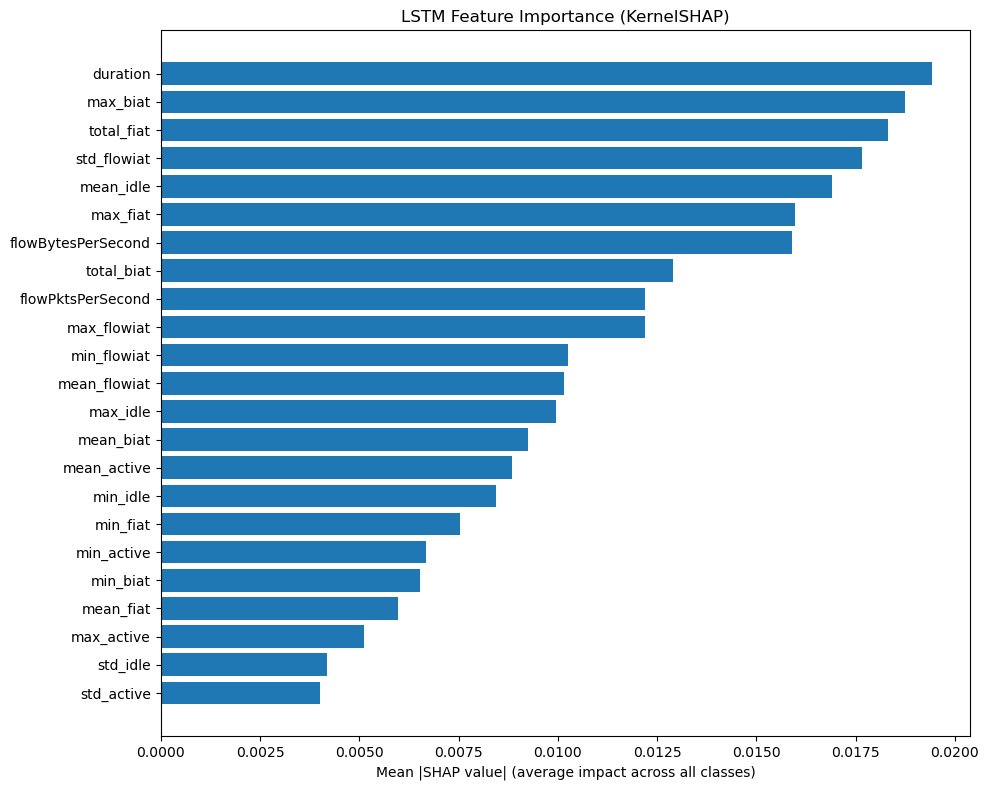

Top 5 most important features:
duration: 0.0194
max_biat: 0.0187
total_fiat: 0.0183
std_flowiat: 0.0177
mean_idle: 0.0169


In [13]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = list(X_train.columns)

# Overall importance: average absolute SHAP value across all classes and samples
overall_importance = np.abs(shap_values).mean(axis=(0, 2))

# Sort features by importance
sorted_idx = np.argsort(overall_importance)[::-1]

plt.figure(figsize=(10, 8))
plt.barh(range(len(feature_names)), overall_importance[sorted_idx][::-1])
plt.yticks(range(len(feature_names)), [feature_names[i] for i in sorted_idx][::-1])
plt.xlabel('Mean |SHAP value| (average impact across all classes)')
plt.title('LSTM Feature Importance (KernelSHAP)')
plt.tight_layout()
plt.savefig('../results/lstm_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
for i in sorted_idx[:5]:
    print(f"{feature_names[i]}: {overall_importance[i]:.4f}")